# Data Loading, Preprocessing, and EDA

This notebook loads `medical_insurance.csv`, checks data quality, creates EDA plots, splits the data into train/validation/test, encodes/scales features, and creates the preprocessing output.

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib pytest

In [3]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [5]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "medical_insurance.csv"
EDA_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "figures" / "eda"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project root: /content
Dataset path: /content/data/raw/medical_insurance.csv
Dataset exists: True


In [6]:
REQUIRED_COLUMNS = [
    "age",
    "gender",
    "bmi",
    "children",
    "discount_eligibility",
    "region",
    "expenses",
    "premium",
]


def normalize_column_names(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )
    return df


if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH}")

raw_df = pd.read_csv(DATA_PATH)
df = normalize_column_names(raw_df)

missing_columns = [col for col in REQUIRED_COLUMNS if col not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df = df[REQUIRED_COLUMNS].copy()

numeric_cols = ["age", "bmi", "children", "expenses", "premium"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Loaded dataset successfully.")
print("Shape:", df.shape)
display(df.head())

Loaded dataset successfully.
Shape: (1338, 8)


,age,gender,bmi,children,discount_eligibility,region,expenses,premium
0,19,female,27.9,0,yes,southwest,16884.92,168.8492
1,18,male,33.8,1,no,southeast,1725.55,17.2555
2,28,male,33.0,3,no,southeast,4449.46,44.4946
3,33,male,22.7,0,no,northwest,21984.47,439.6894
4,32,male,28.9,0,no,northwest,3866.86,77.3372


In [7]:
quality_table = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_values": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
})

display(quality_table)

print("Duplicate rows:", df.duplicated().sum())
print("Shape check:", df.shape)

assert df.shape[1] == 8, "Dataset should have 8 columns."
assert df.shape[0] == 1338, "Dataset should have 1,338 rows."

,dtype,missing_values,missing_percent,unique_values
age,int64,0,0.0,47
gender,object,0,0.0,2
bmi,float64,0,0.0,275
children,int64,0,0.0,6
discount_eligibility,object,0,0.0,2
region,object,0,0.0,4
expenses,float64,0,0.0,1337
premium,float64,0,0.0,1337


Duplicate rows: 1
Shape check: (1338, 8)


In [8]:
TARGET_COL = "expenses"
EXCLUDED_FROM_X = ["expenses", "premium"]

feature_columns = [col for col in df.columns if col not in EXCLUDED_FROM_X]

print("Target column:", TARGET_COL)
print("Excluded from model features:", EXCLUDED_FROM_X)
print("Candidate input features:", feature_columns)

Target column: expenses
Excluded from model features: ['expenses', 'premium']
Candidate input features: ['age', 'gender', 'bmi', 'children', 'discount_eligibility', 'region']


In [9]:
print("Numeric summary:")
display(df.describe().T)

print("Categorical summary:")
display(df[["gender", "discount_eligibility", "region"]].describe().T)

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.0000,51.0000,64.0000
bmi,1338.0,30.665471,6.098382,16.0000,26.30000,30.4000,34.7000,53.1000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.0000,2.0000,5.0000
expenses,1338.0,13270.422414,12110.011240,1121.8700,4740.28750,9382.0300,16639.9150,63770.4300
premium,1338.0,262.874685,292.532178,11.2187,87.35425,174.9974,342.9089,1983.1064


Categorical summary:


,count,unique,top,freq
gender,1338,2,male,676
discount_eligibility,1338,2,no,1064
region,1338,4,southeast,364


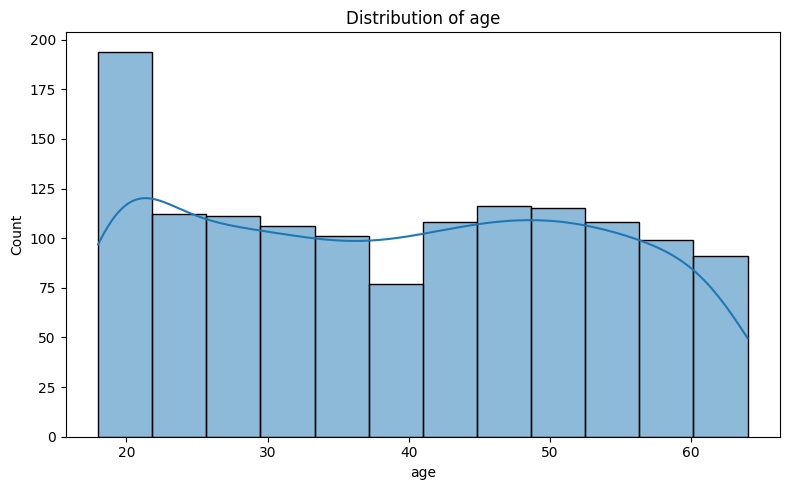

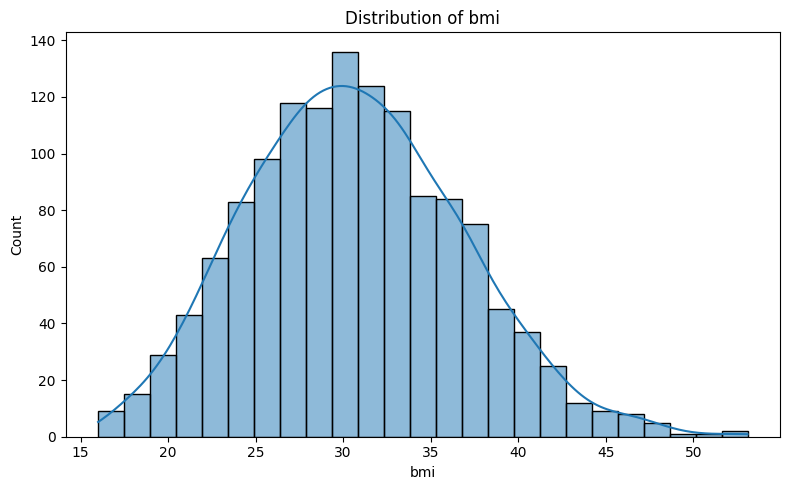

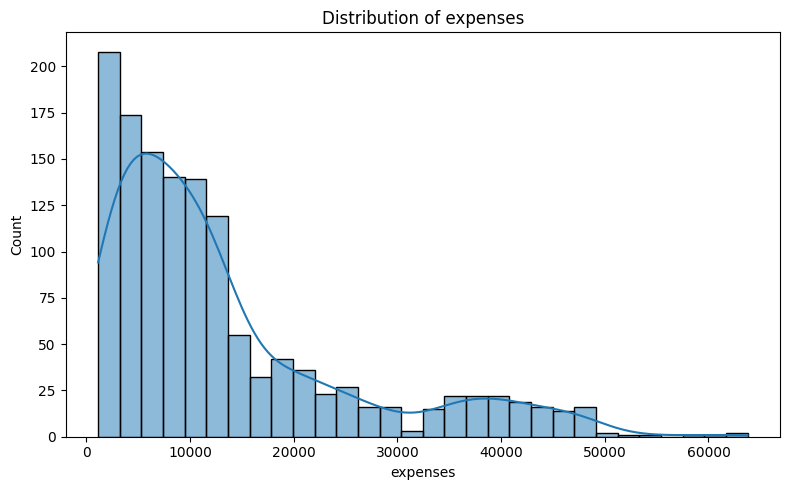

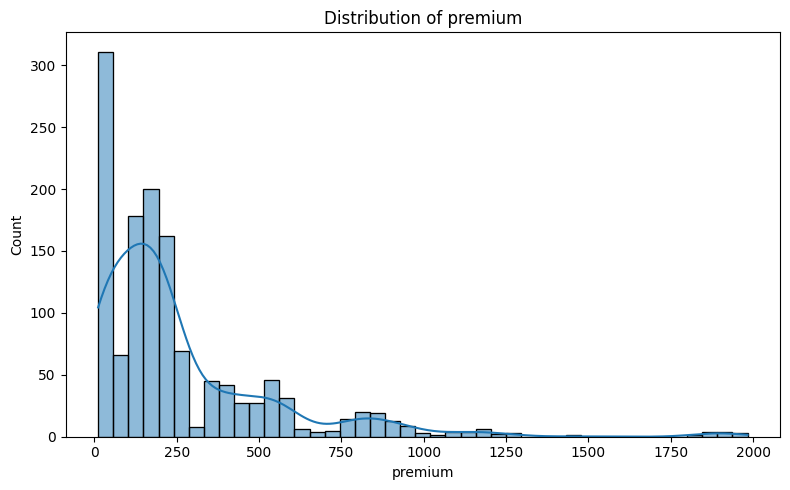

In [10]:
for col in ["age", "bmi", "expenses", "premium"]:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(EDA_OUTPUT_DIR / f"{col}_distribution.png", dpi=300)
    plt.show()

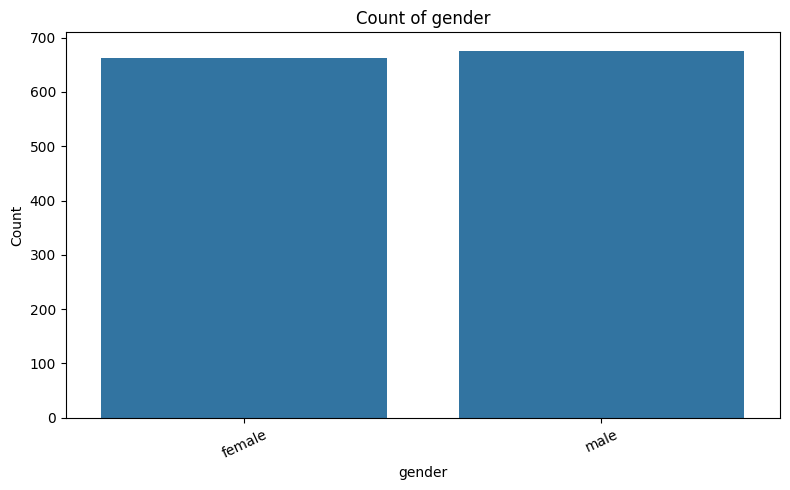

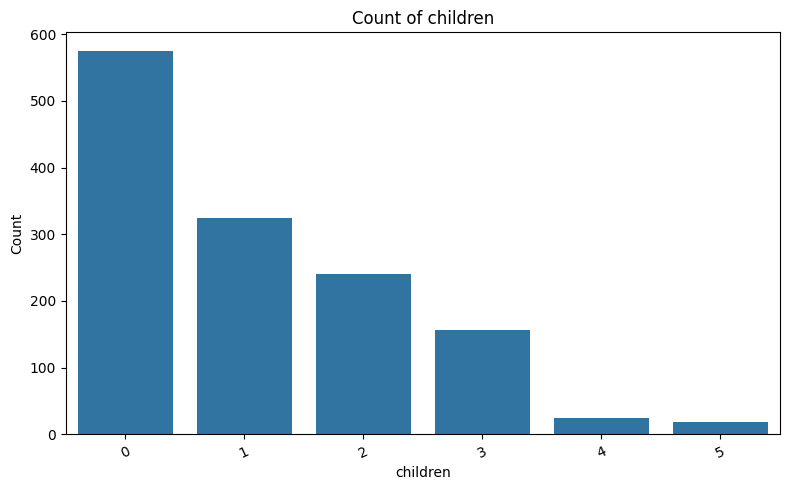

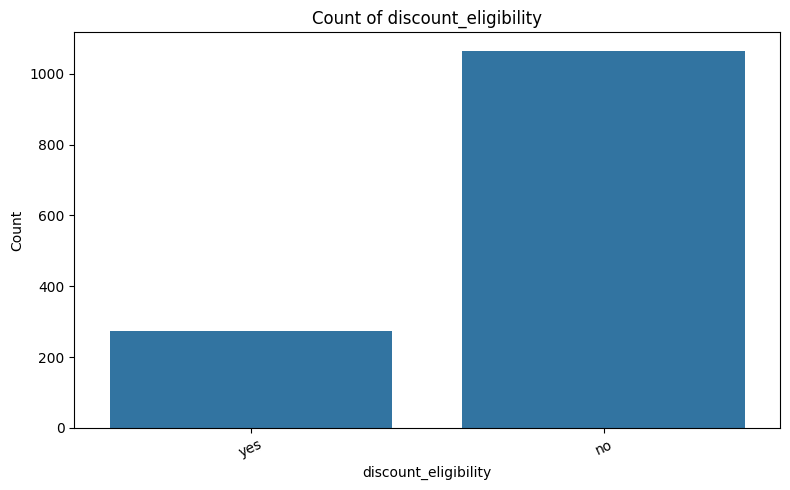

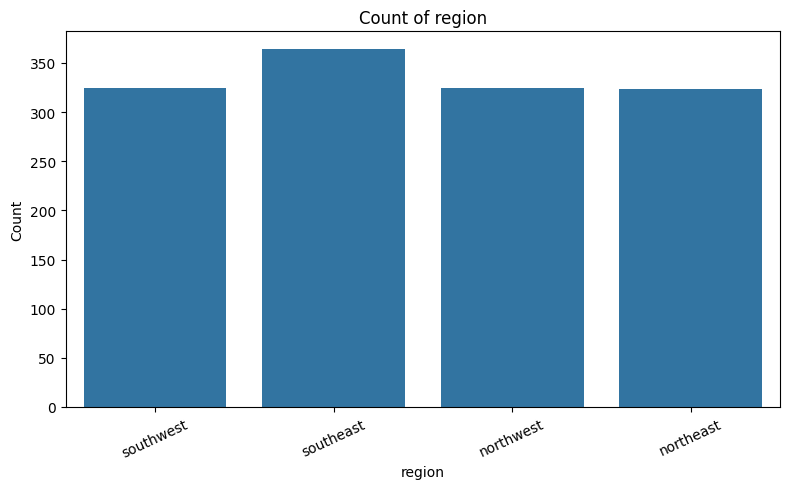

In [11]:
for col in ["gender", "children", "discount_eligibility", "region"]:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col)
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(EDA_OUTPUT_DIR / f"{col}_count.png", dpi=300)
    plt.show()

,age,bmi,children,expenses,premium
age,1.000000,0.109341,0.042469,0.299008,0.530327
bmi,0.109341,1.000000,0.012645,0.198576,0.177888
children,0.042469,0.012645,1.000000,0.067998,0.042417
expenses,0.299008,0.198576,0.067998,1.000000,0.854005
premium,0.530327,0.177888,0.042417,0.854005,1.000000


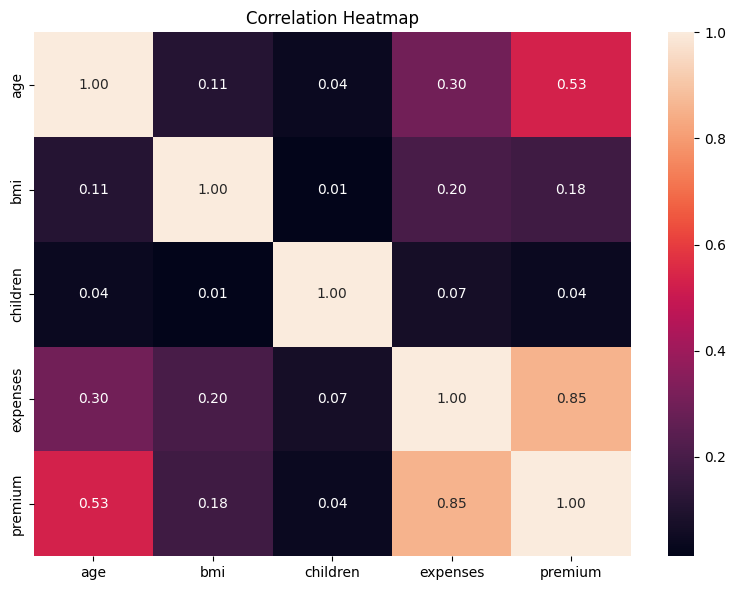

In [12]:
numeric_df = df[["age", "bmi", "children", "expenses", "premium"]]
corr_matrix = numeric_df.corr()

display(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(EDA_OUTPUT_DIR / "correlation_heatmap.png", dpi=300)
plt.show()

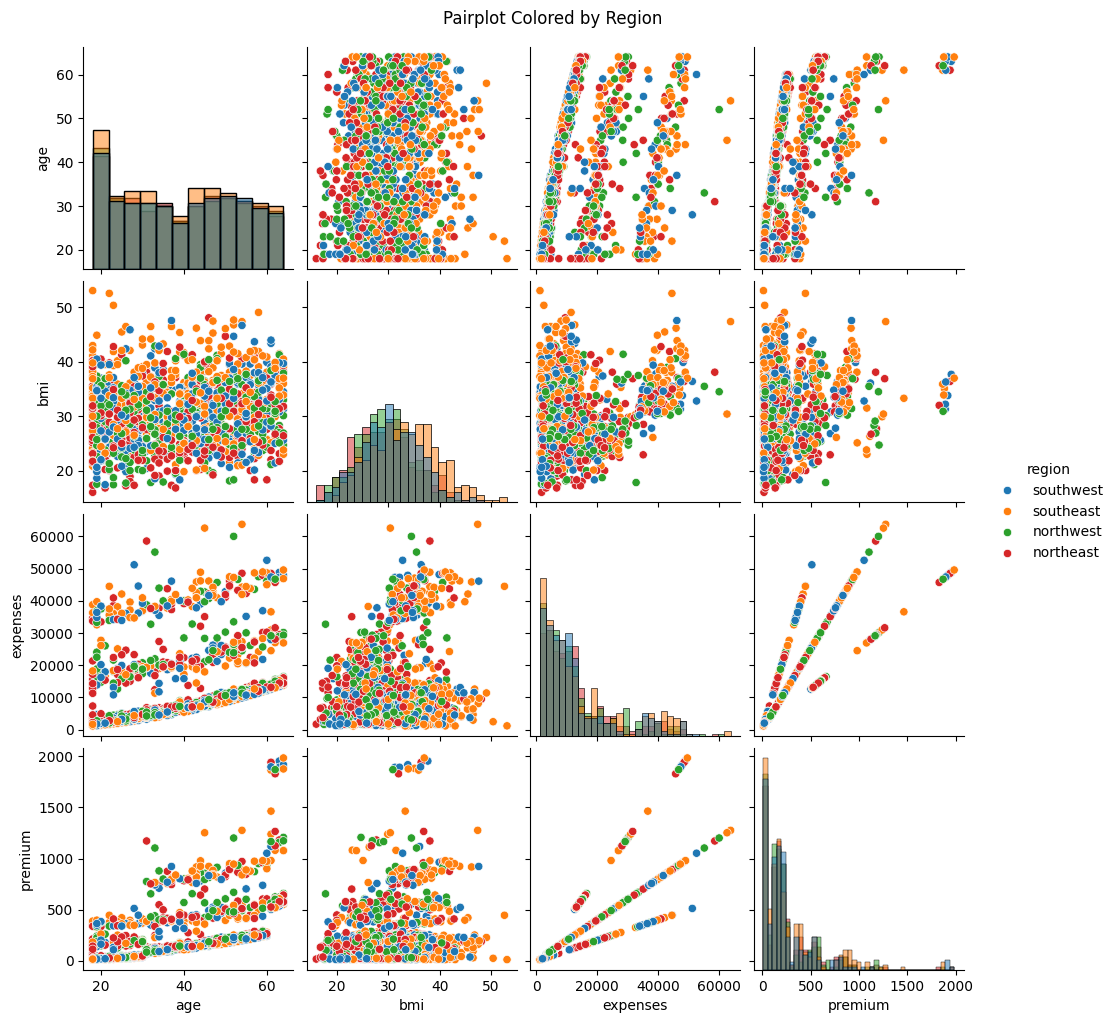

In [13]:
pairplot = sns.pairplot(
    df,
    vars=["age", "bmi", "expenses", "premium"],
    hue="region",
    diag_kind="hist"
)
pairplot.fig.suptitle("Pairplot Colored by Region", y=1.02)
pairplot.savefig(EDA_OUTPUT_DIR / "pairplot_by_region.png", dpi=300)
plt.show()

In [14]:
RANDOM_STATE = 42

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=RANDOM_STATE,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("Total rows:", len(train_df) + len(val_df) + len(test_df))

assert len(train_df) + len(val_df) + len(test_df) == len(df)

Train shape: (1070, 8)
Validation shape: (134, 8)
Test shape: (134, 8)
Total rows: 1338


In [15]:
NUMERIC_FEATURES = ["age", "bmi", "children"]
BINARY_FEATURES = ["gender", "discount_eligibility"]
CATEGORICAL_FEATURES = ["region"]


def encode_binary_column(series: pd.Series, column_name: str) -> pd.Series:
    cleaned = series.astype(str).str.strip().str.lower()

    if column_name == "gender":
        mapping = {
            "male": 1,
            "m": 1,
            "female": 0,
            "f": 0,
            "1": 1,
            "0": 0,
        }
    elif column_name == "discount_eligibility":
        mapping = {
            "yes": 1,
            "y": 1,
            "true": 1,
            "1": 1,
            "eligible": 1,
            "no": 0,
            "n": 0,
            "false": 0,
            "0": 0,
            "not eligible": 0,
            "not_eligible": 0,
        }
    else:
        raise ValueError(f"No encoding rule for column: {column_name}")

    encoded = cleaned.map(mapping)

    if encoded.isna().any():
        bad_values = cleaned[encoded.isna()].unique()
        raise ValueError(f"Unexpected values in {column_name}: {bad_values}")

    return encoded.astype(int)


numeric_medians = train_df[NUMERIC_FEATURES].median()
category_modes = {}

for col in BINARY_FEATURES + CATEGORICAL_FEATURES:
    category_modes[col] = train_df[col].mode(dropna=True)[0]

train_for_fit = train_df.copy()

for col in NUMERIC_FEATURES:
    train_for_fit[col] = train_for_fit[col].fillna(numeric_medians[col])

for col in BINARY_FEATURES + CATEGORICAL_FEATURES:
    train_for_fit[col] = train_for_fit[col].fillna(category_modes[col])

region_columns = list(pd.get_dummies(train_for_fit["region"], prefix="region").columns)

scaler = StandardScaler()
scaler.fit(train_for_fit[NUMERIC_FEATURES])

artifacts = {
    "numeric_medians": numeric_medians,
    "category_modes": category_modes,
    "region_columns": region_columns,
    "scaler": scaler,
}

print("Preprocessing artifacts fitted.")
print("Region dummy columns:", region_columns)

Preprocessing artifacts fitted.
Region dummy columns: ['region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


In [16]:
def transform_features(input_df: pd.DataFrame, artifacts: dict) -> pd.DataFrame:
    temp = input_df.copy()

    for col in NUMERIC_FEATURES:
        temp[col] = temp[col].fillna(artifacts["numeric_medians"][col])

    for col in BINARY_FEATURES + CATEGORICAL_FEATURES:
        temp[col] = temp[col].fillna(artifacts["category_modes"][col])

    X_numeric = pd.DataFrame(
        artifacts["scaler"].transform(temp[NUMERIC_FEATURES]),
        columns=NUMERIC_FEATURES,
        index=temp.index
    )

    X_binary = pd.DataFrame(index=temp.index)
    for col in BINARY_FEATURES:
        X_binary[col] = encode_binary_column(temp[col], col)

    X_region = pd.get_dummies(temp["region"], prefix="region")
    X_region = X_region.reindex(columns=artifacts["region_columns"], fill_value=0)

    X = pd.concat([X_numeric, X_binary, X_region], axis=1)
    X = X.astype(float).reset_index(drop=True)

    return X


X_train = transform_features(train_df, artifacts)
X_val = transform_features(val_df, artifacts)
X_test = transform_features(test_df, artifacts)

y_train = train_df[TARGET_COL].astype(float).reset_index(drop=True)
y_val = val_df[TARGET_COL].astype(float).reset_index(drop=True)
y_test = test_df[TARGET_COL].astype(float).reset_index(drop=True)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("Feature names:", list(X_train.columns))

display(X_train.head())

X_train: (1070, 9)
X_val: (134, 9)
X_test: (134, 9)
y_train: (1070,)
Feature names: ['age', 'bmi', 'children', 'gender', 'discount_eligibility', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,gender,discount_eligibility,region_northeast,region_northwest,region_southeast,region_southwest
0,0.472227,-1.748572,0.734336,0.0,0.0,0.0,1.0,0.0,0.0
1,0.543313,-1.036704,-0.911192,0.0,0.0,1.0,0.0,0.0,0.0
2,0.898745,-0.937373,-0.911192,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.025379,0.618804,3.202629,0.0,0.0,0.0,0.0,1.0,0.0
4,1.040918,-1.500246,1.557100,0.0,0.0,0.0,1.0,0.0,0.0


In [17]:
m1_data = {
    "X_train": X_train,
    "X_val": X_val,
    "X_test": X_test,
    "y_train": y_train,
    "y_val": y_val,
    "y_test": y_test,
    "feature_names": list(X_train.columns),
}

print("M1 output keys:")
print(list(m1_data.keys()))

for key in ["X_train", "X_val", "X_test"]:
    print(key, m1_data[key].shape, "missing values:", m1_data[key].isna().sum().sum())

for key in ["y_train", "y_val", "y_test"]:
    print(key, m1_data[key].shape, "missing values:", m1_data[key].isna().sum())

assert "expenses" not in X_train.columns
assert "premium" not in X_train.columns
assert X_train.isna().sum().sum() == 0
assert X_val.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0
assert np.isfinite(X_train.values).all()
assert np.isfinite(X_val.values).all()
assert np.isfinite(X_test.values).all()

print("All M1 contract checks passed.")

M1 output keys:
['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test', 'feature_names']
X_train (1070, 9) missing values: 0
X_val (134, 9) missing values: 0
X_test (134, 9) missing values: 0
y_train (1070,) missing values: 0
y_val (134,) missing values: 0
y_test (134,) missing values: 0
All M1 contract checks passed.


In [18]:
joblib.dump(artifacts, MODELS_DIR / "preprocessor_artifacts.pkl")

X_train.to_csv(PROCESSED_DIR / "X_train.csv", index=False)
X_val.to_csv(PROCESSED_DIR / "X_val.csv", index=False)
X_test.to_csv(PROCESSED_DIR / "X_test.csv", index=False)
y_train.to_csv(PROCESSED_DIR / "y_train.csv", index=False)
y_val.to_csv(PROCESSED_DIR / "y_val.csv", index=False)
y_test.to_csv(PROCESSED_DIR / "y_test.csv", index=False)

with open(PROCESSED_DIR / "feature_names.txt", "w") as f:
    for feature in m1_data["feature_names"]:
        f.write(feature + "\n")

print("Saved preprocessing artifacts to:", MODELS_DIR / "preprocessor_artifacts.pkl")
print("Saved processed outputs to:", PROCESSED_DIR)

Saved preprocessing artifacts to: /content/models/preprocessor_artifacts.pkl
Saved processed outputs to: /content/data/processed


In [19]:
X_train_cluster = X_train[["age", "bmi"]]

print("M2 clustering input shape:", X_train_cluster.shape)
display(X_train_cluster.head())

M2 clustering input shape: (1070, 2)


,age,bmi
0,0.472227,-1.748572
1,0.543313,-1.036704
2,0.898745,-0.937373
3,-0.025379,0.618804
4,1.040918,-1.500246


In [20]:
print("M3 X_train shape:", X_train.shape)
print("M3 y_train shape:", y_train.shape)
print("M3 X_val shape:", X_val.shape)
print("M3 y_val shape:", y_val.shape)

M3 X_train shape: (1070, 9)
M3 y_train shape: (1070,)
M3 X_val shape: (134, 9)
M3 y_val shape: (134,)
